In [39]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio import features, warp

chemins

In [40]:
# Paths configuration
RAW_PATH = '../dattest/rawtest/'
IMAGES_PATH = os.path.join(RAW_PATH, 'images')
ANNOTATIONS_PATH = os.path.join(RAW_PATH, 'annotations')
PROCESSED_PATH = '../dattest/processedtest/'

# Create processed folder if it does not exist
os.makedirs(PROCESSED_PATH, exist_ok=True)

print("Chemins configurés avec succès.")
print("Images path      :", IMAGES_PATH)
print("Annotations path :", ANNOTATIONS_PATH)
print("Processed path   :", PROCESSED_PATH)

Chemins configurés avec succès.
Images path      : ../dattest/rawtest/images
Annotations path : ../dattest/rawtest/annotations
Processed path   : ../dattest/processedtest/


Fonction de normalisation de l’image

In [41]:
def normalize_image(image_data):
    """
    Normalize image values and convert shape from (C, H, W) to (H, W, C).
    """
    image_data = image_data.astype(np.float32)

    # Normalize if values are still in 0-255 range
    if image_data.max() > 1.0:
        image_data = image_data / 255.0

    # Convert from channels-first to channels-last
    image_data = np.moveaxis(image_data, 0, -1)

    return image_data

Fonction pour charger les features GeoJSON

Cette fonction lit un fichier GeoJSON et retourne sa liste de features.

Chaque feature peut représenter :

une route
un bâtiment
ou un autre objet annoté

In [42]:
def load_geojson_features(geojson_path):
    """
    Load the list of features from a GeoJSON file.
    """
    with open(geojson_path, 'r', encoding='utf-8') as f:
        gj = json.load(f)

    if 'features' in gj:
        return gj['features']
    
    return []

Fonction utilitaire pour enlever l’extension

In [43]:
def base_name(path):
    """
    Return the file name without extension.
    """
    return os.path.splitext(os.path.basename(path))[0]

Lire les fichiers locaux

In [44]:
# List all local image files
image_files = sorted([
    os.path.join(IMAGES_PATH, f)
    for f in os.listdir(IMAGES_PATH)
    if f.lower().endswith('.tif')
])

# List all local annotation files
annot_files = sorted([
    os.path.join(ANNOTATIONS_PATH, f)
    for f in os.listdir(ANNOTATIONS_PATH)
    if f.lower().endswith('.geojson')
])

print("Nombre d'images trouvées :", len(image_files))
print("Nombre d'annotations trouvées :", len(annot_files))

Nombre d'images trouvées : 20
Nombre d'annotations trouvées : 20


Inspection d’un GeoJSON

In [46]:
# Inspect one annotation file to understand the structure of the dataset
sample_geojson = annot_files[0] if len(annot_files) > 0 else None

if sample_geojson is not None:
    with open(sample_geojson, "r", encoding="utf-8") as f:
        gj = json.load(f)

    print("Fichier testé :", os.path.basename(sample_geojson))
    print("Nombre de features :", len(gj.get("features", [])))

    for i, feat in enumerate(gj.get("features", [])[:10]):
        print(f"\nFeature {i}")
        print("Geometry type :", feat.get("geometry", {}).get("type"))
        print("Properties :", feat.get("properties", {}))
else:
    print("Aucun fichier GeoJSON trouvé.")

Fichier testé : 0_15_63.geojson
Nombre de features : 20

Feature 0
Geometry type : LineString
Properties : {'id': 'way/847402035', 'building': None, 'flooded': None, 'highway': 'residential', 'lanes': '2', 'surface': 'paved', 'oneway': None, 'bridge': None, 'layer': None, 'tunnel': None, 'type': None, 'image_id': '10500500C4DD7000', 'location': 'Germany_Training_Public'}

Feature 1
Geometry type : LineString
Properties : {'id': 'way/847402036', 'building': None, 'flooded': None, 'highway': 'residential', 'lanes': '2', 'surface': 'paved', 'oneway': None, 'bridge': None, 'layer': None, 'tunnel': None, 'type': None, 'image_id': '10500500C4DD7000', 'location': 'Germany_Training_Public'}

Feature 2
Geometry type : LineString
Properties : {'id': 'way/847406275', 'building': None, 'flooded': None, 'highway': 'residential', 'lanes': '2', 'surface': 'paved', 'oneway': None, 'bridge': 'yes', 'layer': None, 'tunnel': None, 'type': None, 'image_id': '10500500C4DD7000', 'location': 'Germany_Trainin

Construction des paires locales image–annotation par suffixe

In [47]:
matched_local_pairs = []

for annot_path in annot_files:
    annot_name = base_name(annot_path)

    found_img = None
    for img_path in image_files:
        img_name = base_name(img_path)

        # Match by tile suffix
        if annot_name in img_name:
            found_img = img_path
            break

    if found_img is not None:
        matched_local_pairs.append((found_img, annot_path))

# Remove duplicates if any
matched_local_pairs = list(dict.fromkeys(matched_local_pairs))

print(f"Paires locales trouvées : {len(matched_local_pairs)}")
for pair in matched_local_pairs[:5]:
    print(pair)

Paires locales trouvées : 20
('../dattest/rawtest/images\\1040050035DC3B00_0_15_63.tif', '../dattest/rawtest/annotations\\0_15_63.geojson')
('../dattest/rawtest/images\\1040050035DC3B00_0_15_65.tif', '../dattest/rawtest/annotations\\0_15_65.geojson')
('../dattest/rawtest/images\\1040050035DC3B00_0_15_66.tif', '../dattest/rawtest/annotations\\0_15_66.geojson')
('../dattest/rawtest/images\\1040050035DC3B00_0_15_67.tif', '../dattest/rawtest/annotations\\0_15_67.geojson')
('../dattest/rawtest/images\\1040050035DC3B00_0_15_68.tif', '../dattest/rawtest/annotations\\0_15_68.geojson')


Fonction pour créer deux masques séparés

lit l’image satellite
lit le GeoJSON
sépare les routes et les bâtiments
reprojette les géométries dans le repère de l’image
rasterise deux masques :
mask_roads
mask_buildings

In [48]:
def create_separate_masks_from_geojson(image_path, geojson_path):
    """
    Read a satellite image and its GeoJSON annotation, then create:
    - one binary mask for roads
    - one binary mask for buildings

    Roads are identified using:
    - geometry type = LineString
    - property 'highway' is not None

    Buildings are identified using:
    - geometry type = Polygon
    - property 'building' == 'yes'
    """
    with rasterio.open(image_path) as src:
        img_crs = src.crs
        img_shape = src.shape
        img_transform = src.transform
        image_data = src.read()

    features_list = load_geojson_features(geojson_path)

    road_geometries = []
    building_geometries = []

    for feat in features_list:
        geom = feat.get('geometry')
        props = feat.get('properties', {})

        if geom is None:
            continue

        geom_type = geom.get('type')

        try:
            # Reproject geometry into the image coordinate system
            reproj_geom = warp.transform_geom(
                'EPSG:4326',
                img_crs,
                geom
            )

            # Roads
            if geom_type == 'LineString' and props.get('highway') is not None:
                road_geometries.append((reproj_geom, 1))

            # Buildings
            elif geom_type == 'Polygon' and props.get('building') == 'yes':
                building_geometries.append((reproj_geom, 1))

        except Exception:
            continue

    # Rasterize roads
    if len(road_geometries) == 0:
        mask_roads = np.zeros(img_shape, dtype=np.uint8)
    else:
        mask_roads = features.rasterize(
            road_geometries,
            out_shape=img_shape,
            transform=img_transform,
            fill=0,
            dtype=np.uint8
        )

    # Rasterize buildings
    if len(building_geometries) == 0:
        mask_buildings = np.zeros(img_shape, dtype=np.uint8)
    else:
        mask_buildings = features.rasterize(
            building_geometries,
            out_shape=img_shape,
            transform=img_transform,
            fill=0,
            dtype=np.uint8
        )

    return image_data, mask_roads, mask_buildings

Fonction pour extraire les patches

Cette fonction découpe l’image et les masques en patches de taille 256x256.

Elle garde seulement les patches qui contiennent suffisamment d’information :

soit en routes
soit en bâtiments

In [49]:
def extract_patches_two_masks(image, mask_roads, mask_buildings, patch_size=256, stride=128, min_info_ratio=0.005):
    """
    Extract image patches with two separate masks:
    - one for roads
    - one for buildings

    A patch is kept if at least one class contains enough information.
    """
    img_patches = []
    road_patches = []
    building_patches = []

    h, w = mask_roads.shape

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            img_patch = image[i:i+patch_size, j:j+patch_size]
            road_patch = mask_roads[i:i+patch_size, j:j+patch_size]
            building_patch = mask_buildings[i:i+patch_size, j:j+patch_size]

            # Check patch size
            if img_patch.shape[:2] != (patch_size, patch_size):
                continue
            if road_patch.shape != (patch_size, patch_size):
                continue
            if building_patch.shape != (patch_size, patch_size):
                continue

            # Information ratio for each class
            info_ratio_roads = np.sum(road_patch > 0) / (patch_size * patch_size)
            info_ratio_buildings = np.sum(building_patch > 0) / (patch_size * patch_size)

            # Keep patch if at least one class is sufficiently represented
            if max(info_ratio_roads, info_ratio_buildings) >= min_info_ratio:
                img_patches.append(img_patch)
                road_patches.append(road_patch)
                building_patches.append(building_patch)

    return img_patches, road_patches, building_patches

Paramètres du patching

In [50]:
PATCH_SIZE = 256
STRIDE = 128
MIN_INFO_RATIO = 0.005

print("Paramètres de patching :")
print("PATCH_SIZE     =", PATCH_SIZE)
print("STRIDE         =", STRIDE)
print("MIN_INFO_RATIO =", MIN_INFO_RATIO)

Paramètres de patching :
PATCH_SIZE     = 256
STRIDE         = 128
MIN_INFO_RATIO = 0.005


Boucle principale de preprocessing

Cette boucle applique le preprocessing à toutes les paires locales.

Pour chaque paire :

création des masques
normalisation de l’image
extraction des patches
ajout au dataset global

In [51]:
X_all = []
Y_roads_all = []
Y_buildings_all = []

for idx, (img_path, annot_path) in enumerate(matched_local_pairs):
    print(f"\nTraitement [{idx+1}/{len(matched_local_pairs)}]")
    print("Image      :", os.path.basename(img_path))
    print("Annotation :", os.path.basename(annot_path))

    try:
        # Create separate masks
        image_data, mask_roads, mask_buildings = create_separate_masks_from_geojson(img_path, annot_path)

        # Normalize image
        image_norm = normalize_image(image_data)

        # Extract patches
        img_patches, road_patches, building_patches = extract_patches_two_masks(
            image_norm,
            mask_roads,
            mask_buildings,
            patch_size=PATCH_SIZE,
            stride=STRIDE,
            min_info_ratio=MIN_INFO_RATIO
        )

        # Add patches to global dataset
        X_all.extend(img_patches)
        Y_roads_all.extend(road_patches)
        Y_buildings_all.extend(building_patches)

        print(f"Patches extraits : {len(img_patches)}")

    except Exception as e:
        print(f"Erreur sur {os.path.basename(img_path)} : {e}")

print("\nPrétraitement terminé.")
print(f"Nombre total de patches image      : {len(X_all)}")
print(f"Nombre total de patches routes     : {len(Y_roads_all)}")
print(f"Nombre total de patches bâtiments  : {len(Y_buildings_all)}")


Traitement [1/20]
Image      : 1040050035DC3B00_0_15_63.tif
Annotation : 0_15_63.geojson
Patches extraits : 24

Traitement [2/20]
Image      : 1040050035DC3B00_0_15_65.tif
Annotation : 0_15_65.geojson
Patches extraits : 0

Traitement [3/20]
Image      : 1040050035DC3B00_0_15_66.tif
Annotation : 0_15_66.geojson
Patches extraits : 0

Traitement [4/20]
Image      : 1040050035DC3B00_0_15_67.tif
Annotation : 0_15_67.geojson
Patches extraits : 19

Traitement [5/20]
Image      : 1040050035DC3B00_0_15_68.tif
Annotation : 0_15_68.geojson
Patches extraits : 21

Traitement [6/20]
Image      : 1040050035DC3B00_0_15_69.tif
Annotation : 0_15_69.geojson
Patches extraits : 1

Traitement [7/20]
Image      : 1040050035DC3B00_0_15_70.tif
Annotation : 0_15_70.geojson
Patches extraits : 0

Traitement [8/20]
Image      : 1040050035DC3B00_0_16_63.tif
Annotation : 0_16_63.geojson
Patches extraits : 0

Traitement [9/20]
Image      : 1040050035DC3B00_0_16_66.tif
Annotation : 0_16_66.geojson
Patches extraits : 

Conversion en tableaux NumPy

In [52]:
X_all = np.array(X_all, dtype=np.float32)

Y_roads_all = np.array(Y_roads_all, dtype=np.uint8)
Y_buildings_all = np.array(Y_buildings_all, dtype=np.uint8)

# Add channel dimension for deep learning compatibility
Y_roads_all = np.expand_dims(Y_roads_all, axis=-1)
Y_buildings_all = np.expand_dims(Y_buildings_all, axis=-1)

print("Shape X_all            :", X_all.shape)
print("Shape Y_roads_all      :", Y_roads_all.shape)
print("Shape Y_buildings_all  :", Y_buildings_all.shape)

Shape X_all            : (157, 256, 256, 3)
Shape Y_roads_all      : (157, 256, 256, 1)
Shape Y_buildings_all  : (157, 256, 256, 1)


Statistiques globales

In [53]:
road_pixels = np.sum(Y_roads_all)
building_pixels = np.sum(Y_buildings_all)

total_road_pixels = Y_roads_all.size
total_building_pixels = Y_buildings_all.size

print("===== STATISTIQUES GLOBALES =====")
print("Pixels routes total       :", road_pixels)
print("Pixels bâtiments total    :", building_pixels)
print("Ratio routes global       :", road_pixels / total_road_pixels)
print("Ratio bâtiments global    :", building_pixels / total_building_pixels)

===== STATISTIQUES GLOBALES =====
Pixels routes total       : 42092
Pixels bâtiments total    : 395603
Ratio routes global       : 0.004090910504578026
Ratio bâtiments global    : 0.03844855241714769


Affichage d’un exemple aléatoire

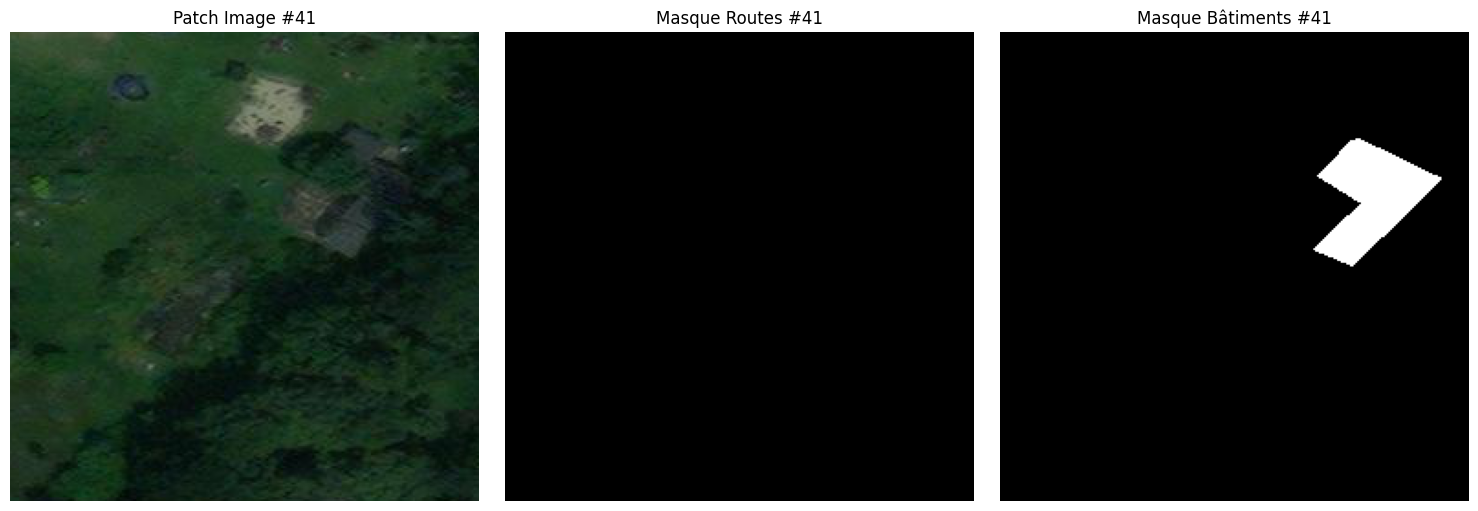

In [54]:
import random

if len(X_all) > 0:
    idx = random.randint(0, len(X_all) - 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(X_all[idx])
    plt.title(f"Patch Image #{idx}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_roads_all[idx].squeeze(), cmap='gray')
    plt.title(f"Masque Routes #{idx}")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(Y_buildings_all[idx].squeeze(), cmap='gray')
    plt.title(f"Masque Bâtiments #{idx}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Aucun patch trouvé.")

Exemple riche en routes

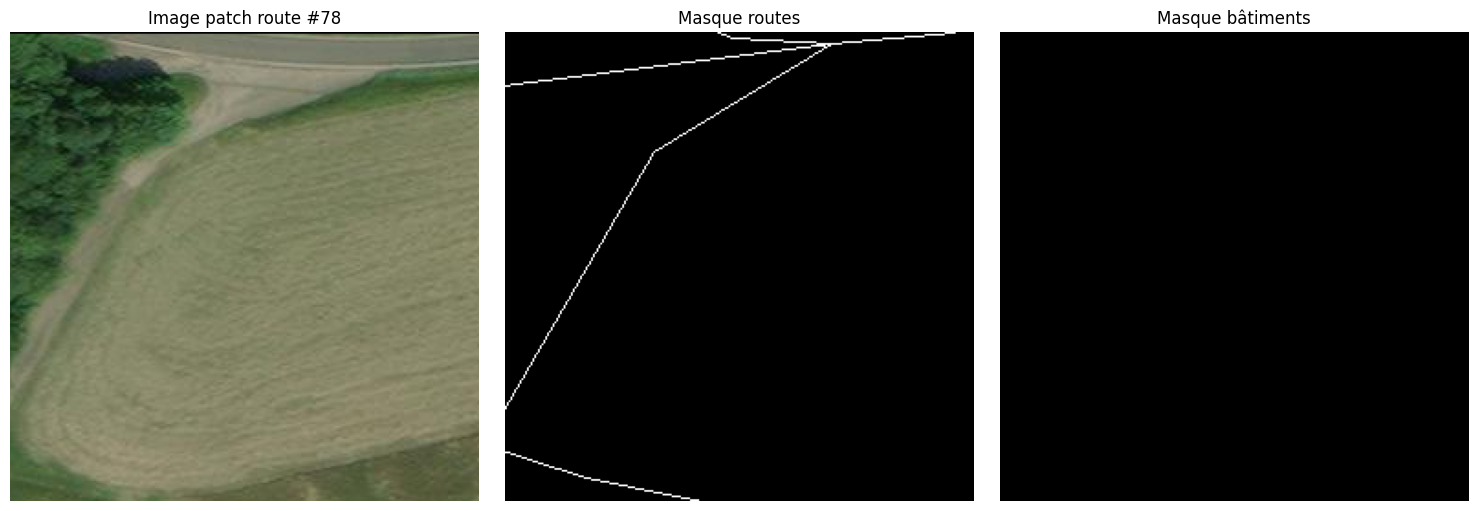

In [55]:
if len(Y_roads_all) > 0:
    road_ratios = [np.sum(mask.squeeze()) / mask.squeeze().size for mask in Y_roads_all]
    idx_road = int(np.argmax(road_ratios))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(X_all[idx_road])
    plt.title(f"Image patch route #{idx_road}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_roads_all[idx_road].squeeze(), cmap='gray')
    plt.title("Masque routes")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(Y_buildings_all[idx_road].squeeze(), cmap='gray')
    plt.title("Masque bâtiments")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Exemple riche en bâtiments

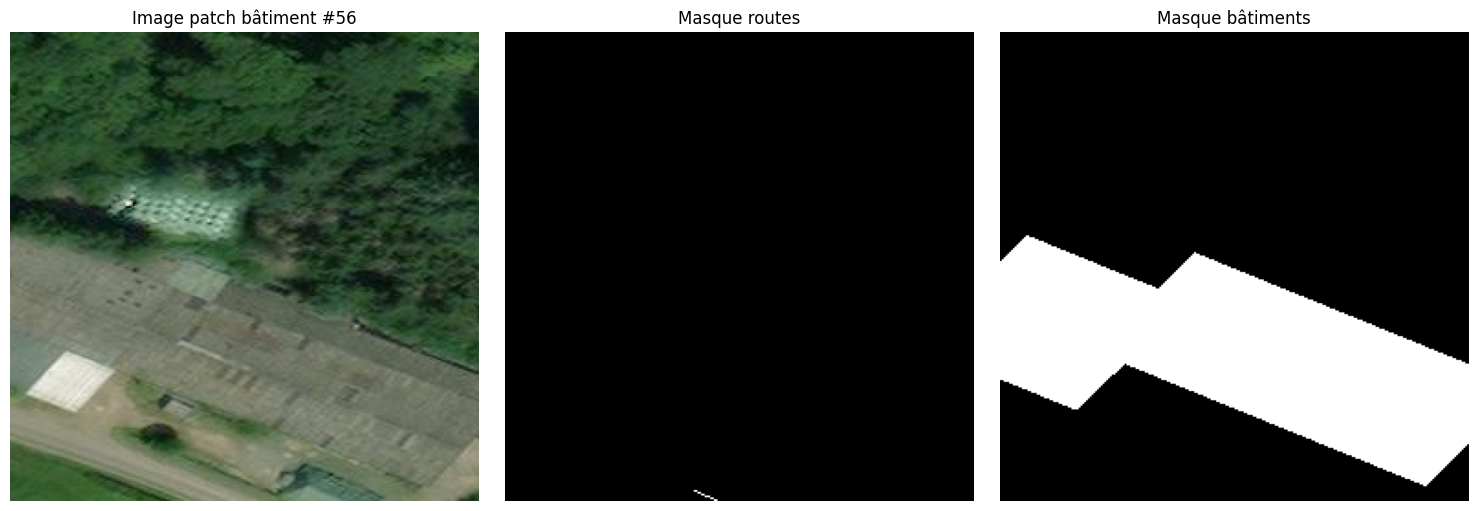

In [56]:
if len(Y_buildings_all) > 0:
    building_ratios = [np.sum(mask.squeeze()) / mask.squeeze().size for mask in Y_buildings_all]
    idx_building = int(np.argmax(building_ratios))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(X_all[idx_building])
    plt.title(f"Image patch bâtiment #{idx_building}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_roads_all[idx_building].squeeze(), cmap='gray')
    plt.title("Masque routes")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(Y_buildings_all[idx_building].squeeze(), cmap='gray')
    plt.title("Masque bâtiments")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Sauvegarde finale

In [57]:
np.save(os.path.join(PROCESSED_PATH, 'X_all.npy'), X_all)
np.save(os.path.join(PROCESSED_PATH, 'Y_roads_all.npy'), Y_roads_all)
np.save(os.path.join(PROCESSED_PATH, 'Y_buildings_all.npy'), Y_buildings_all)

print("Dataset sauvegardé avec succès.")
print("Fichiers générés :")
print("- X_all.npy")
print("- Y_roads_all.npy")
print("- Y_buildings_all.npy")

Dataset sauvegardé avec succès.
Fichiers générés :
- X_all.npy
- Y_roads_all.npy
- Y_buildings_all.npy
